In [6]:
import os
from dotenv import load_dotenv

load_dotenv()
from util import split_waveform_by_timestamps, aggregate_timestamps

token = os.environ.get("HUGGINGFACE_ACCESS_TOKEN")
wav_file = "sample.wav"

In [7]:
from pyannote.audio import Pipeline
from pyannote.audio.pipelines.utils.hook import ProgressHook
import torch
import torchaudio

pipeline = Pipeline.from_pretrained(
    "pyannote/speaker-diarization-3.1", use_auth_token=token
)

pipeline.to(torch.device("cuda"))

waveform, sample_rate = torchaudio.load(wav_file)

with ProgressHook() as hook:
    diarization = pipeline(
        {"waveform": waveform, "sample_rate": sample_rate}, num_speakers=2, hook=hook
    )

Output()

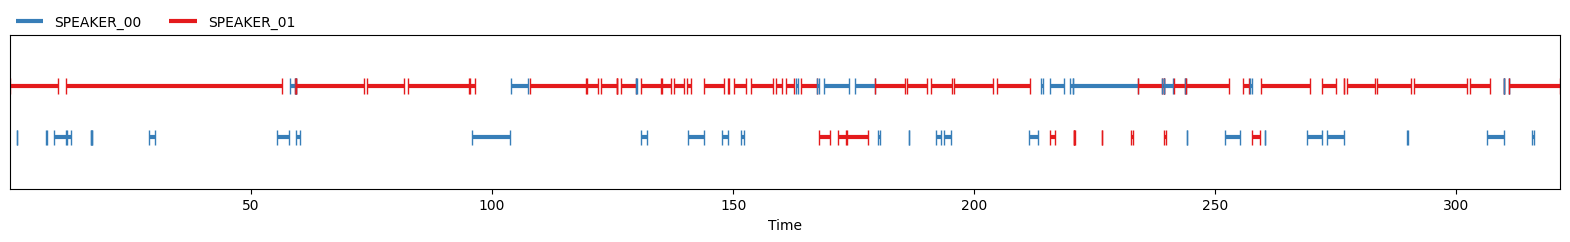

In [8]:
diarization

In [9]:
timestamps = []

for turn, _, speaker in diarization.itertracks(yield_label=True):
    timestamps.append((turn.start, turn.end, speaker))

In [10]:
split_waveform_by_timestamps(waveform, sample_rate, "out", timestamps, sortby="speaker")